# 0. Importing necessary libraries

In [2]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
import matplotlib.pyplot as plt


# 1. Getting the data from the dataset

In [3]:
# Training Data
train_data = datasets.FashionMNIST(
    root="img_data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

# Testing Data
test_data = datasets.FashionMNIST(
    root="img_data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 272kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.07MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.2MB/s]


# 2. Model(summary)
The model class will contain two parts ->

1. **Decoding** part in which we will use Conv2d, ReLU, MaxPool2d to sample down the input(lower the dimensions of input), that is what compression is right?
Compression basically is if a picture/image can be defined with 724 pixels then can be able to define the image/picture using 144 pixels too.But not that accurate as the 724 pixels one.So this is what we will be doing using the above fns we will sample down the image to compressed image.So the orginal image in divided into no.of hidden_units x (1x28x28(one image resolution)).
******************************************************************************
2. **Encoding** part in which we will use ConvTranspose2d, ReLU, Sigmoid activation fn. So ConvTranspose2d is just the mirror of MaxPool2d in which MaxPool2d scales down the image pixels(taking avg of 4 pixels -> to one pixel when kernel size = 2) where as the ConvTranspose2d expands/scales up the pixels.After using the ConvTranspose2d and ReLU fn we use sigmoid activation fn at the bz makes the values in the pixels in range of 0 to 1 i.e.,[0,1]

So this how basically our model works. Where can the error occur suppose take one pixel from image which has value of **0.8** after undergoing the encoding and decoding the same pixel value is **0.5**. So we can see the error, thats why we use loss fn called Mean Squared Loss(MSE) we evaluate the loss using this fn and then backpropagate it and then use Adam optimizer(saw in internet for this model it is better than SGD)
**Loss for that one pixel is 0.09**

In order to reduce this loss we will also create a **training loop* in which the model learns how to encode and decode the given image accurately and see the **before** and **after** results.


## 2.1 Building the model class
=> **ReLU - Rectified Linear Unit** - In simple terms,
  if x < 0: y=0 else: x=y

In [30]:
from PIL.Image import ENCODERS
class EncodeDecodeModelV0(nn.Module):
  def __init__(self,
               hidden_units: int=16):
    super().__init__()
    # Let hidden_units be h
    # Encoding part(1x28x28 -> hx14x14)
    self.encoder = nn.Sequential(
        nn.Conv2d(1,
                  hidden_units,     # What this does, 1x28x28 -> hx28x28
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2), # hx28x28 -> hx14x14
        nn.Conv2d(hidden_units,
                  hidden_units,     # Nothing happens we know why!
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2) # hx14x14 -> hx7x7(Compressed Version of the img)
    )
    # Decoding part(hx14x14 -> 1x28x28)
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(hidden_units,
                           hidden_units,  # hx7x7 -> hx14x14(How this is done hard to explain but can be seen in CNN official website)
                           kernel_size=2,
                           stride=2),
        nn.ReLU(),
        nn.ConvTranspose2d(hidden_units,
                           1,             # hx14x14 -> 1x28x28(We got the shape of the image as we inputted but the point is the values inside each pixel is same as the input image? If not, want we can do. Let's see)
                           kernel_size=2,
                           stride=2),
        nn.Sigmoid()
    )

  # Overwriting the forward fn(IMP!)
  def forward(self, x):
    return self.decoder(self.encoder(x))

  # Lets create a encode fn to just get the compressed img
  def encode(self, x):
    return self.encoder(x)

## 2.2 Creating a new instance of the model/ Initializing the model class


In [42]:
model_0 = EncodeDecodeModelV0(hidden_units=64)


## 2.3 First sample from train dataset and passing through the untrained model and seeing the results

In [43]:
img, label = train_data[1]

# Setting a seed for reproducibility
torch.manual_seed(42)

with torch.inference_mode():
  com_img = model_0.encode(img) # com_img = compressed image
  recon_img = model_0(img) # recon_img = reconstructed image

# Printing the shapes of the input image, com image & recon image
print(f'Input shape -> {img.shape}')
print(f'Compressed shape -> {com_img.shape}')
print(f'Reconstructed shape -> {recon_img.shape}')
# As expected now lets see whether both the images(orginal image and reconstructed image)took the same!
# As the model is not trained, MSE will be more so we can't expect both the images to look the same!

Input shape -> torch.Size([1, 28, 28])
Compressed shape -> torch.Size([64, 7, 7])
Reconstructed shape -> torch.Size([1, 28, 28])


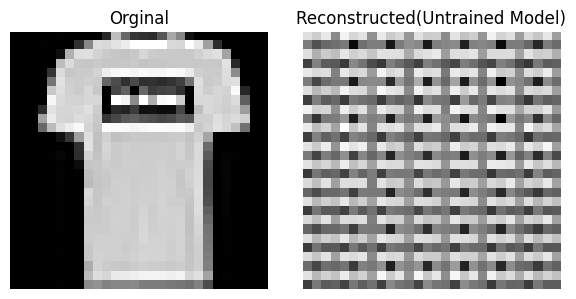

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Visualizing the orginal image
axes[0].imshow(img.squeeze(0), cmap='gray')
axes[0].set_title('Orginal')
axes[0].axis('off')

# Visualizing the reconstructed image
axes[1].imshow(recon_img.squeeze(0).numpy(), cmap='gray') # Why only converting the recon_img from tensor -> to numpy not img, as img is a simple tensor already in cpu the cpu can convert it automatically but as the model outputs recon_img which as gradient tracking etc. we need to expilcility convert to numpy.
axes[1].set_title('Reconstructed(Untrained Model)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 3. We need to train the model.

## 3.1 Creating dataloader


In [45]:
from torch.utils.data import DataLoader
# Setting the batch size
BATCH_SIZE = 32

# Creating the data
loader = DataLoader(train_data,
                    batch_size=BATCH_SIZE,
                    shuffle=True)


## 3.2 Setting up the loss fn and the optimizer


In [46]:
# Loss fn
loss_fn = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=1e-3) # 1e-1 = 0.1

## 3.3 Setting up the training loop for the model

In [47]:
torch.manual_seed(42)

# Setting up the no.of epochs
epochs = 5

### Training
for epoch in range(epochs):
  for imgs, _ in loader:
    # Predicting the output
    recon = model_0(imgs)

    # Find the loss
    loss = loss_fn(recon, # Here basically the input and the target are the same
                   imgs)

    # Set the optimizer to zero gradient
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Optimizer step
    optimizer.step()
  print(f'Epoch: {epoch} | Loss: {loss}')

Epoch: 0 | Loss: 0.003468818496912718
Epoch: 1 | Loss: 0.0029394945595413446
Epoch: 2 | Loss: 0.0026411262806504965
Epoch: 3 | Loss: 0.0021906078327447176
Epoch: 4 | Loss: 0.002423470839858055


## 3.4 Plotting the final result

In [48]:
# Lets take sample data from test data to test the trained model
img_1, label_1 = test_data[1]

with torch.inference_mode():
  com_img_1 = model_0.encode(img_1)
  recon_img_1 = model_0(img_1)

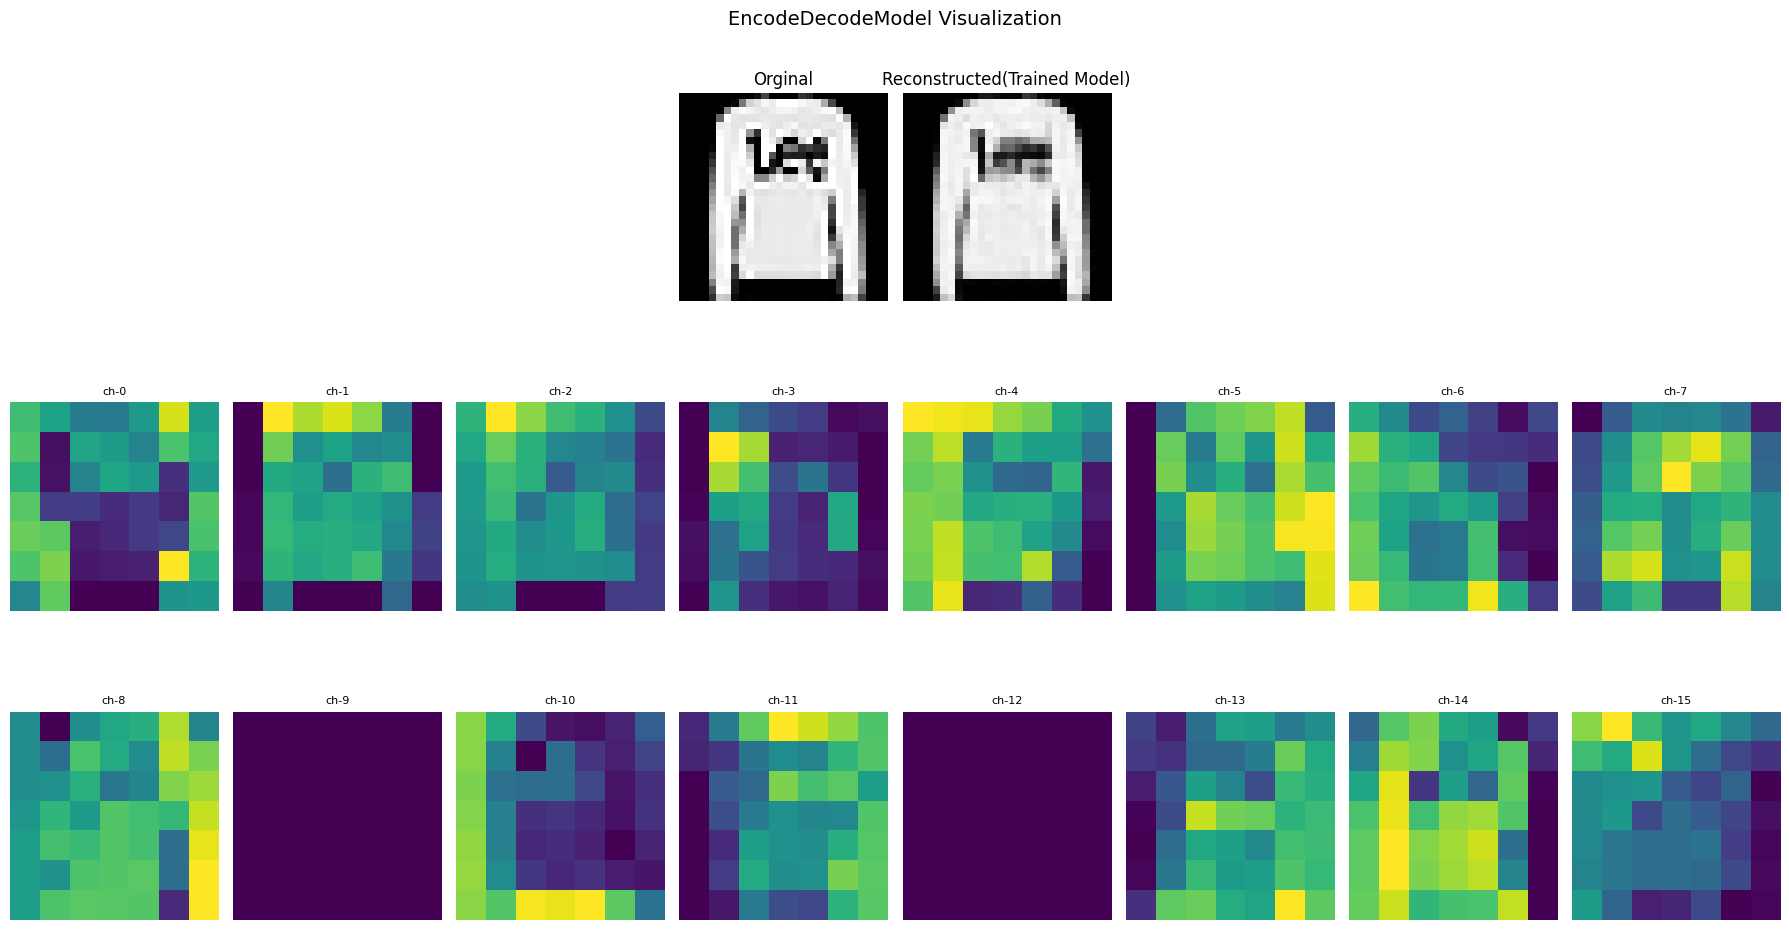

In [51]:
### -------- Plot ---------
# Through this plot we can see the compressed image's all 16 channels
fig, axes = plt.subplots(3, 8, figsize=(18, 10))
fig.suptitle('EncodeDecodeModel Visualization', fontsize=14)

# We have 3 rows and 8 columns to plot
for i in range(8):
  axes[0, i].axis('off')
axes[0, 3].imshow(img_1.squeeze(0), cmap='gray')
axes[0, 3].set_title('Orginal')
axes[0, 4].imshow(recon_img_1.squeeze(0).numpy(), cmap='gray')
axes[0, 4].set_title('Reconstructed(Trained Model)')

com_img_1_np = com_img_1.squeeze(0).numpy()
for i in range(16):
  row = 1 + i//8
  col = i % 8
  axes[row, col].imshow(com_img_1_np[i], cmap='viridis') # Tells what color to use when displaying gray-scale colors/single channel colors
  axes[row, col].set_title(f'ch-{i}', fontsize=8)
  axes[row, col].axis('off')

plt.tight_layout()
plt.show()